Подключение библиотек

In [ ]:
import yfinance as yf
import pandas as pd



## Получение данных

In [50]:
data = yf.download('MSFT',period='2y',interval='1h')

[*********************100%***********************]  1 of 1 completed


In [51]:
data.head(10)

Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
Datetime,,,,,
2024-04-10 13:30:00+00:00,420.640015,424.029999,420.301605,422.209991,3772735
2024-04-10 14:30:00+00:00,421.000000,422.480011,419.709991,420.640015,2109070
2024-04-10 15:30:00+00:00,420.535004,421.130005,419.760010,421.040009,1279244
2024-04-10 16:30:00+00:00,421.774994,422.869995,419.994995,420.595001,1419114
2024-04-10 17:30:00+00:00,421.690002,422.619995,420.220001,421.739990,1496267
2024-04-10 18:30:00+00:00,422.109985,426.279999,421.029999,421.799988,1344912
2024-04-10 19:30:00+00:00,423.130005,423.755005,421.290009,422.170013,1786998
2024-04-11 13:30:00+00:00,423.809906,426.700012,422.359985,425.820007,3870979


In [52]:
data.to_csv('data/msft.csv')

## Анализ данных

In [28]:
df = pd.read_csv('data/amd.csv')

In [29]:
df.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,AMD,AMD,AMD,AMD,AMD
1,Datetime,NaN,NaN,NaN,NaN,NaN
2,2024-04-10 13:30:00+00:00,167.60000610351562,169.77520751953125,166.2899932861328,166.6999969482422,14116876
3,2024-04-10 14:30:00+00:00,167.82000732421875,168.16000366210938,166.02000427246094,167.63999938964844,8751962
4,2024-04-10 15:30:00+00:00,165.8699951171875,167.83970642089844,165.6699981689453,167.81500244140625,6356358


In [30]:
df = df.drop(index=[0, 1]) # Удаляем первые две строки с метаданными
df = df.reset_index(drop=True) # Сбрасываем индексы после удаления строк
df = df.rename(columns={"Price": "Datetime"}) # Переименовываем столбец 'Price' в 'Datetime'
df.head()

,Datetime,Close,High,Low,Open,Volume
0,2024-04-10 13:30:00+00:00,167.60000610351562,169.77520751953125,166.2899932861328,166.6999969482422,14116876
1,2024-04-10 14:30:00+00:00,167.82000732421875,168.16000366210938,166.02000427246094,167.63999938964844,8751962
2,2024-04-10 15:30:00+00:00,165.8699951171875,167.83970642089844,165.6699981689453,167.81500244140625,6356358
3,2024-04-10 16:30:00+00:00,165.21009826660156,166.44000244140625,164.41000366210938,165.8699951171875,8531089
4,2024-04-10 17:30:00+00:00,164.52999877929688,165.59750366210938,164.22999572753906,165.1999969482422,6737683


In [31]:
df.head()

,Datetime,Close,High,Low,Open,Volume
0,2024-04-10 13:30:00+00:00,167.60000610351562,169.77520751953125,166.2899932861328,166.6999969482422,14116876
1,2024-04-10 14:30:00+00:00,167.82000732421875,168.16000366210938,166.02000427246094,167.63999938964844,8751962
2,2024-04-10 15:30:00+00:00,165.8699951171875,167.83970642089844,165.6699981689453,167.81500244140625,6356358
3,2024-04-10 16:30:00+00:00,165.21009826660156,166.44000244140625,164.41000366210938,165.8699951171875,8531089
4,2024-04-10 17:30:00+00:00,164.52999877929688,165.59750366210938,164.22999572753906,165.1999969482422,6737683


In [33]:
df["Datetime"].min(), df["Datetime"].max() # Проверяем диапазон дат в данных

('2024-04-10 13:30:00+00:00', '2026-04-09 19:30:00+00:00')

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3483 entries, 0 to 3482
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Datetime  3483 non-null   str  
 1   Close     3483 non-null   str  
 2   High      3483 non-null   str  
 3   Low       3483 non-null   str  
 4   Open      3483 non-null   str  
 5   Volume    3483 non-null   str  
dtypes: str(6)
memory usage: 163.4 KB


In [35]:
price_cols = ["Close", "High", "Low", "Open"]

df[price_cols] = (
    df[price_cols]
    .apply(pd.to_numeric, errors="coerce")
    .round(2)
)


<Axes: xlabel='Datetime'>

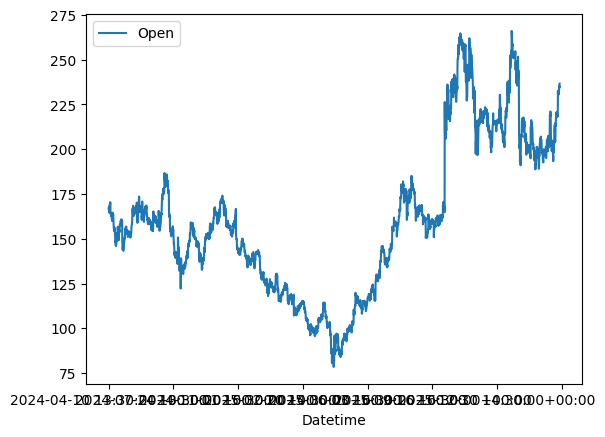

In [36]:
df.plot(x="Datetime", y="Open") # Строим график открытия акций SBER

<Axes: xlabel='Datetime'>

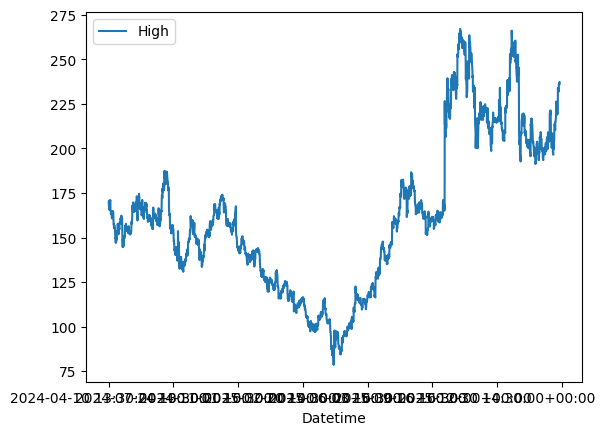

In [38]:
df.plot(x="Datetime", y="High") # Строим график максимальных цен акций SBER

In [39]:
df[["Open", "Close", "Low", "High"]].corr() # Проверяем корреляцию между ценами открытия, закрытия, минимума и максимума

,Open,Close,Low,High
Open,1.000000,0.999250,0.999563,0.999595
Close,0.999250,1.000000,0.999612,0.999583
Low,0.999563,0.999612,1.000000,0.999287
High,0.999595,0.999583,0.999287,1.000000
